In [2]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [5]:
iris = load_iris()
X = iris.data

y = iris.target

<Axes: >

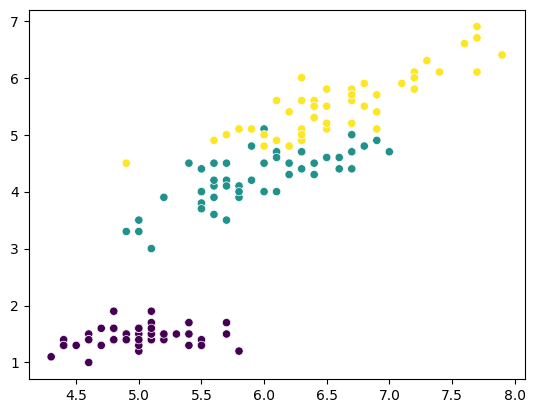

In [8]:
# visualize
sns.scatterplot(x=X[:,0], y=X[:,2], c=y)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled  = scaler.fit_transform(X)


In [16]:
# optional - dimentionality reduction using pca
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

In [17]:
# elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)


<Axes: >

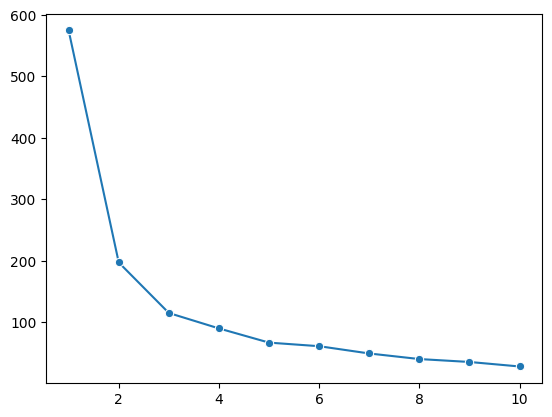

In [18]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

<Axes: >

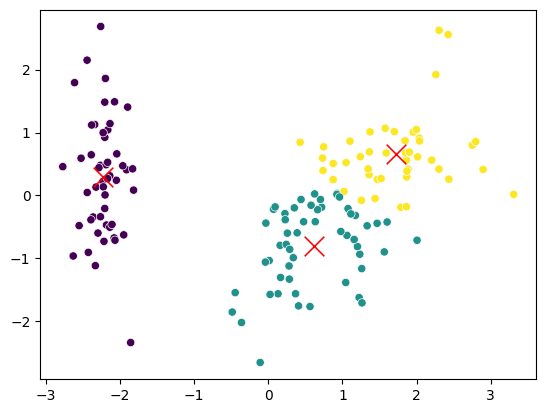

In [25]:
# Kmeans
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1],marker="x",c="red", s=200)